# Notebook 06 — Spatial Containment

## Overview

In notebook 01 we established that a `Pizza` *has as a part* a `PizzaCrust`. That mereological relation is compositional and identity-defining: the crust constitutes the pizza. But during baking the pizza sits *inside* an oven, and during delivery inside a box — these are spatial containment relations, not parthood.

SULO provides two spatial properties for this:

| Property | Direction | Transitive? |
|---|---|---|
| `sulo:contains` | container → contained entity | Yes |
| `sulo:isIn` | contained entity → container | Yes (inverse of `contains`) |

Containment is transitive: a fridge that contains a delivery box also contains the pizza inside the box. But containment does not propagate into `hasPart`: the box does not *have* the pizza's crust as a part.

Beyond static containment, this notebook introduces four `LocationRole` subtypes (`ContainmentRole`, `ContainedRole`, `SurfacePositionRole`, `OnTopPositionRole`) and three spatial process classes that use these roles to demarcate *when* and *why* a spatial relation holds between specific individuals.

## Learning Objectives

1. Distinguish `sulo:hasPart` (mereological, identity-defining) from `sulo:contains` (spatial, reversible) and explain why containment does not entail parthood
2. Use `sulo:contains` and its inverse `sulo:isIn` to model spatial relations, and verify transitivity using `INDIRECT_contains`
3. Define four disjoint `LocationRole` subtypes to distinguish enclosure from surface support, at both container and occupant sides
4. Define classes using `isIn some ContainerClass` and verify individual classification by the reasoner
5. Model spatial process classes whose participants carry role individuals, demarcating when a spatial relation holds
6. Query spatial relations using SPARQL property paths over the asserted RDF graph

## Getting started

The following cell loads SULO, the `pro` ontology, and the pizza ontology built in notebook 05.

In [177]:
import sys, os
# Locate project root (the directory containing lib/) regardless of CWD
for _p in ['.', '..', '../..']:
    if os.path.isdir(os.path.join(_p, 'lib')):
        os.chdir(_p); sys.path.insert(0, os.getcwd()); break

from lib.helpers import *
onto_path.append(".")
sulo = get_ontology("dist/sulo.owl").load()
pro  = get_ontology("dist/pro.owl").load()
pizza = get_ontology("dist/pizza-05.owl").load()
pizza.imported_ontologies.append(sulo)
pizza.imported_ontologies.append(pro)

result = safe_call_reasoner(pizza)
print("Consistent:", result["ok"])
print("Classes in pizza ontology:", len(list(pizza.classes())))

Consistent: True
Classes in pizza ontology: 71


## Spatial Roles and Container Subclasses

To model containment and surface placement precisely, we introduce four `LocationRole` subtypes in `pro`:

| Role | Meaning |
|---|---|
| `ContainmentRole` | Played by an object that spatially encloses another (box, oven) |
| `ContainedRole` | Played by an object that is spatially enclosed |
| `SurfacePositionRole` | Played by an object whose surface supports another (table, plate) |
| `OnTopPositionRole` | Played by an object resting on the surface of another |

All four roles are disjoint. We then define three `sulo:SpatialObject` subclasses relevant to the pizza lifecycle:

| Class | Role it bears | Context |
|---|---|---|
| `PizzaOven` | `ContainmentRole` | encloses the pizza during baking |
| `PizzaDeliveryBox` | `ContainmentRole` | encloses the pizza during delivery |
| `Table` | `SurfacePositionRole` | supports the pizza after unboxing |

In [178]:
with pro:
    class ContainmentRole(pro.LocationRole):
        """Role played by an object that spatially contains another."""
        label = [locstr("containment role", "en")]

    class ContainedRole(pro.LocationRole):
        """Role played by an object that is spatially contained within another."""
        label = [locstr("contained role", "en")]

    class OnTopPositionRole(pro.LocationRole):
        """An OnTopPositionRole is a role borne by an object that occupies a position spatially
            above another object within some contextual arrangement or process."""
        label = [locstr("on top position role", "en")]

    class SurfacePositionRole(pro.LocationRole):
        """An SurfacePositionRole is a role borne by an object that occupies a position spatially 
            below another object within some contextual arrangement or process."""
        label = [locstr("surface position role", "en")]

    AllDisjoint([ContainmentRole, ContainedRole, OnTopPositionRole,SurfacePositionRole])


with pizza:

    class PizzaOven(sulo.SpatialObject):
        """A heated enclosed chamber in which pizzas are baked."""
        label = [locstr("pizza oven", "en")]
        is_a = [sulo.hasFeature.some(ContainmentRole)]

    class PizzaDeliveryBox(sulo.SpatialObject):
        """A box used to transport a pizza from the pizzeria to the customer."""
        label = [locstr("pizza delivery box", "en")]
        is_a = [sulo.hasFeature.some(ContainmentRole)]

    class Table(sulo.SpatialObject):
        """A table."""
        label = [locstr("table", "en")]
        is_a = [sulo.hasFeature.some(pro.SurfacePositionRole)]

    AllDisjoint([PizzaOven, PizzaDeliveryBox, Table])
    
result = safe_call_reasoner(pizza)
print("Consistent:", result["ok"])
print("Spatial role and container classes defined.")

Consistent: True
Spatial role and container classes defined.


## Containment vs Parthood

The key ontological lesson: even though `contains` is transitive *within itself*, it does not propagate into `hasPart`. A `PizzaDeliveryBox` contains the pizza; the pizza has a `PizzaCrust` as a part; but this does **not** mean the box has a crust as a part.

| Property | `hasPart` | `contains` |
|---|---|---|
| Transitivity | Yes | Yes |
| Compositionality | Yes — parts constitute the whole | No |
| Identity-defining | Yes | No |
| Reversible | No | Yes |

We demonstrate this with individuals.

In [179]:
with pizza:
    my_pizza  = pizza.TraditionalFourCheesePizza("pizza_001")
    my_box    = PizzaDeliveryBox("delivery_box_001")
    my_crust  = pizza.PizzaCrust("crust_of_my_pizza")
    my_fridge = sulo.SpatialObject("fridge_001")

    my_pizza.hasDirectPart = [my_crust]
    my_box.contains    = [my_pizza]
    my_fridge.contains = [my_box]

    AllDifferent([my_pizza, my_box, my_crust, my_fridge])

result = safe_call_reasoner(pizza)
print("Consistent:", result["ok"])

# Helper: show only named individuals (filter out anonymous class expressions)
def named_inds(lst):
    return [x.name for x in lst if hasattr(x, 'name') and isinstance(x.name, str) and not isinstance(x, ThingClass)]

# Transitivity of contains: fridge contains box → fridge contains pizza
print("\nfridge direct contains:   ", named_inds(my_fridge.contains))
print("fridge INDIRECT_contains: ", named_inds(my_fridge.INDIRECT_contains))

# hasPart does NOT propagate through contains
print("\nbox hasPart (expected empty):         ", my_box.hasPart)
print("box INDIRECT_hasPart (only itself):   ", named_inds(my_box.INDIRECT_hasPart))

Consistent: True

fridge direct contains:    ['delivery_box_001']
fridge INDIRECT_contains:  ['delivery_box_001', 'pizza_001']

box hasPart (expected empty):          []
box INDIRECT_hasPart (only itself):    ['delivery_box_001']


## A Defined Class: `BoxedPizza`

A `BoxedPizza` is a `Pizza` that is spatially contained in a `PizzaDeliveryBox`. This is a defined class because we give necessary **and** sufficient conditions.

In [180]:
with pizza:
    class BoxedPizza(pizza.Pizza):
        """A pizza that is inside a delivery box."""
        label = [locstr("boxed pizza", "en")]
        equivalent_to = [pizza.Pizza & sulo.isIn.some(PizzaDeliveryBox)]

result = safe_call_reasoner(pizza)
print("Consistent:", result["ok"])

# Classify my_pizza — is it now a BoxedPizza?
inferred = [t for t in my_pizza.is_a if hasattr(t, 'name')]
print("my_pizza inferred types:", inferred)

Consistent: True
my_pizza inferred types: [pizza.TraditionalFourCheesePizza, pizza-05.BoxedPizza]


## Spatial Participants and Temporal Extent

When does the box contain the pizza — and when does it not?

OWL 2 cannot express time-indexed properties directly. But roles give us a principled answer at the instance level: the box encloses the pizza **when a `ContainmentRole` individual borne by the box participates in a specific spatial process**. Outside that process, no such role individual exists.

We define three process classes that capture the pizza's spatial journey from box to table:

| Process | Spatial relation modelled |
|---|---|
| `BoxingThePizza` | pizza acquires `ContainedRole`; box acquires `ContainmentRole` |
| `UnboxingThePizza` | pizza is removed from the box |
| `PlacingPizzaOnTable` | pizza acquires `OnTopPositionRole`; table acquires `SurfacePositionRole` |

At the instance level we create role individuals — each borne by a specific spatial object — and attach them as participants of concrete process individuals, with `precedes` linking the three events in sequence.

In [181]:
with pizza:
    class BoxingThePizza(sulo.Process):
        """The process of placing a pizza into a delivery box."""
        label = [locstr("boxing the pizza", "en")]
        is_a = [
            sulo.hasParticipant.some(ContainedRole & sulo.isFeatureOf.some(pizza.Pizza)),
            sulo.hasParticipant.some(ContainmentRole & sulo.isFeatureOf.some(pizza.PizzaDeliveryBox)),
        ]

    class UnboxingThePizza(sulo.Process):
        """The process of removing a pizza from the delivery box."""
        label = [locstr("unboxing the pizza", "en")]
        is_a = [
            sulo.hasParticipant.some(ContainedRole & sulo.isFeatureOf.some(pizza.Pizza)),
            sulo.hasParticipant.some(ContainmentRole & sulo.isFeatureOf.some(pizza.PizzaDeliveryBox)),
        ]

    class PlacingPizzaOnTable(sulo.Process):
        """The process of placing a pizza on a table."""
        label = [locstr("placing pizza on table", "en")]
        is_a = [
            sulo.hasParticipant.some(OnTopPositionRole & sulo.isFeatureOf.some(pizza.Pizza)),
            sulo.hasParticipant.some(SurfacePositionRole & sulo.isFeatureOf.some(pizza.Table)),
        ]

result = safe_call_reasoner(pizza)
print("Consistent:", result["ok"])

Consistent: True


In [182]:
with pizza:
    # ContainmentRole borne by the box; ContainedRole borne by the pizza
    box_containment_role = ContainmentRole("box_containment_role_001")
    box_containment_role.isFeatureOf = [my_box]

    pizza_contained_role = ContainedRole("pizza_contained_role_001")
    pizza_contained_role.isFeatureOf = [my_pizza]

    # BoxingThePizza: pizza goes into the box
    boxing_001 = BoxingThePizza("pizza_boxing_001")
    boxing_001.hasParticipant = [box_containment_role, pizza_contained_role]

    # UnboxingThePizza: pizza is removed from the box (same roles, different event)
    unboxing_001 = UnboxingThePizza("pizza_unboxing_001")
    unboxing_001.hasParticipant = [box_containment_role, pizza_contained_role]
    boxing_001.precedes = [unboxing_001]

    # PlacingPizzaOnTable: pizza comes to rest on a table surface
    table_001 = Table("table_001")
    table_surface_role = SurfacePositionRole("table_surface_role_001")
    table_surface_role.isFeatureOf = [table_001]

    pizza_ontop_role = OnTopPositionRole("pizza_ontop_position_role_001")
    pizza_ontop_role.isFeatureOf = [my_pizza]

    table_placement_001 = PlacingPizzaOnTable("placing_pizza_on_table_001")
    table_placement_001.hasParticipant = [pizza_ontop_role, table_surface_role]
    unboxing_001.precedes = [table_placement_001]

result = safe_call_reasoner(pizza)
print("Consistent:", result["ok"])

Consistent: True


## Querying Spatial Relations with SPARQL

owlready2's `default_world.sparql()` runs against the asserted RDF graph. A direct `?x a sulo:SpatialObject` query returns only individuals whose type was explicitly asserted — not those inferred via subclass membership.

Two approaches work reliably without a full external triplestore:

**SPARQL 1.1 property paths** traverse the subclass hierarchy at query time:
```sparql
?object rdf:type/rdfs:subClassOf* sulo:SpatialObject .
```

**Python iteration** uses owlready2's internal index:
```python
list(sulo.SpatialObject.instances())
```

The cells below demonstrate role-based SPARQL queries against the asserted graph: finding which process contains the pizza as a `ContainedRole` bearer, and which object is on top of which surface.

In [183]:
# Query 1: In which process does the pizza play a ContainedRole?
list(default_world.sparql("""
    PREFIX sulo: <https://w3id.org/sulo/>
    PREFIX pro: <https://w3id.org/ontostart/pro/>
    PREFIX pizza: <https://w3id.org/ontostart/pizza/>
    SELECT DISTINCT ?process ?role ?object
    {
        ?process sulo:hasParticipant ?role .
        ?role a pro:ContainedRole .
        ?role sulo:isFeatureOf ?object .
        ?object rdf:type/rdfs:subClassOf* pizza:Pizza .
    }
"""))

[[pizza-05.pizza_boxing_001,
  pizza-05.pizza_contained_role_001,
  pizza-05.pizza_001],
 [pizza-05.pizza_unboxing_001,
  pizza-05.pizza_contained_role_001,
  pizza-05.pizza_001]]

In [184]:
# Query 2: What object is resting on top of what surface?
list(default_world.sparql("""
    PREFIX sulo: <https://w3id.org/sulo/>
    PREFIX pro: <https://w3id.org/ontostart/pro/>
    SELECT DISTINCT ?object1 ?object2
    {
        ?process sulo:hasParticipant ?role1, ?role2 .
        ?role1 a pro:OnTopPositionRole .
        ?role1 sulo:isFeatureOf ?object1 .
        ?role2 a pro:SurfacePositionRole .
        ?role2 sulo:isFeatureOf ?object2 .
    }
"""))

[[pizza-05.pizza_001, pizza-05.table_001]]

In [185]:
# Query 3: All individuals that are (directly or via subclass) SpatialObjects
result = safe_call_reasoner(pizza)
list(default_world.sparql("""
    PREFIX sulo: <https://w3id.org/sulo/>
    SELECT DISTINCT ?object
    {
        ?object rdf:type/rdfs:subClassOf* sulo:SpatialObject .
    }
"""))

[[pizza-05.fridge_001],
 [pizza-05.crust_of_my_pizza],
 [pizza-03.quattro_formaggi_001],
 [pizza-05.pizza_001],
 [pizza-05.delivery_box_001],
 [pizza-05.table_001]]

Saved pizza-06.owl
Saved pro.owl


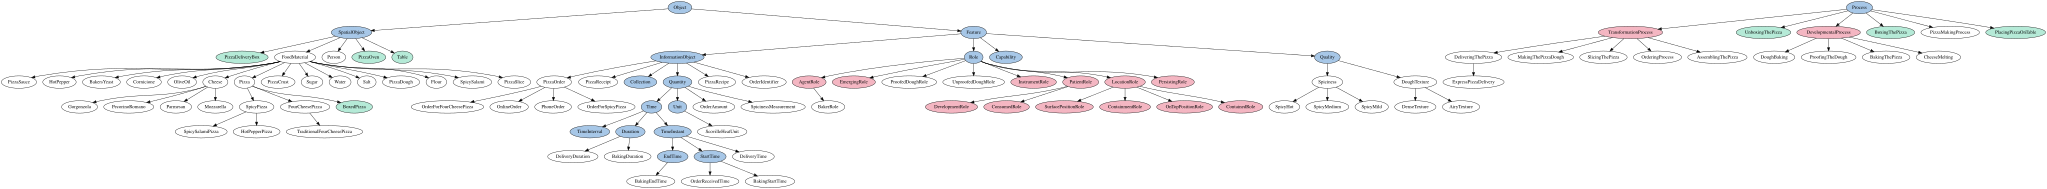

In [186]:
import os
os.makedirs("dist", exist_ok=True)
pizza.save(file="dist/pizza-06.owl", format="rdfxml")
print("Saved pizza-06.owl")

pro.save(file="dist/pro.owl", format="rdfxml")
print("Saved pro.owl")
display(get_color_tree([sulo, pro, pizza]))

---

## Exercise

### YOUR TURN — Disjointness stress test

`ContainmentRole` and `ContainedRole` are declared disjoint. Create a role individual, assert it belongs to both classes, run the reasoner and observe what happens. Then clean up with `destroy_entity` and verify the ontology is consistent again.

In [187]:
# Exercise — your code here

---

## Summary

This notebook added spatial containment to the pizza ontology, distinguishing it from the mereological parthood introduced in notebook 01.

### What we built

**Spatial roles** (added to `pro`, all disjoint)

| Role | Parent | Meaning |
|---|---|---|
| `ContainmentRole` | `LocationRole` | borne by the enclosing object |
| `ContainedRole` | `LocationRole` | borne by the enclosed object |
| `SurfacePositionRole` | `LocationRole` | borne by the supporting surface |
| `OnTopPositionRole` | `LocationRole` | borne by the object resting on the surface |

**Container classes** (in `pizza`)

| Class | Kind | Key axiom |
|---|---|---|
| `PizzaOven` | Primitive | `SpatialObject`; `hasFeature some ContainmentRole` |
| `PizzaDeliveryBox` | Primitive | `SpatialObject`; `hasFeature some ContainmentRole` |
| `Table` | Primitive | `SpatialObject`; `hasFeature some SurfacePositionRole` |
| `BoxedPizza` | Defined | `Pizza & isIn some PizzaDeliveryBox` |

**Spatial process classes** (in `pizza`)

| Process | Participants |
|---|---|
| `BoxingThePizza` | `ContainedRole` borne by pizza; `ContainmentRole` borne by box |
| `UnboxingThePizza` | `ContainedRole` borne by pizza; `ContainmentRole` borne by box |
| `PlacingPizzaOnTable` | `OnTopPositionRole` borne by pizza; `SurfacePositionRole` borne by table |

### Key concepts

**`contains` vs `hasPart`.** Both are transitive, but `contains` is reversible and non-compositional. A box contains a pizza, but the box does not *have* the pizza — or its crust — as a *part*.

**`isIn` as a snapshot classification.** `sulo:isIn` (inverse of `contains`) in `equivalent_to` classifies a pizza by its current containment state — a type-level snapshot useful for querying.

**Roles demarcate when spatial relations hold.** A `ContainmentRole` individual is borne by the box and participates in a specific `BoxingThePizza` event. The disjointness of all four spatial roles ensures that container, contained, surface, and resting object are mutually exclusive within a single relation.

**SPARQL against the asserted graph.** owlready2's SPARQL does not apply subclass inference. Use `rdf:type/rdfs:subClassOf*` property paths to traverse the class hierarchy, or `ClassName.instances()` in Python.